## Spectral Indices


In [3]:
import ee
import geemap
import rasterio
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ID = "riftwaters-505207"
ee.Authenticate()
ee.Initialize(project=PROJECT_ID)

ROI = ee.Geometry.Polygon([
            [36.244378206729166,-0.838827881647561],
            [36.442132112979166,-0.838827881647561],
            [36.442132112979166,-0.6664947946163098],
            [36.244378206729166,-0.6664947946163098],
            [36.244378206729166,-0.838827881647561]
        ])

START_DATE = "2026-01-01"
END_DATE = "2026-02-28"
REGION_NAME = "naivasha"
IMAGE_ID = int(END_DATE.replace("-", ""))




## 1. The indices, and what each is for

| Index | Formula | Best for |
|---|---|---|
| **NDWI** | (Green − NIR) / (Green + NIR) | Open water, but confused by built-up areas |
| **MNDWI** | (Green − SWIR1) / (Green + SWIR1) | Open water, better than NDWI in urban/turbid areas |
| **NDVI** | (NIR − Red) / (NIR + Red) | Vegetation — used as a *negative* signal for water (low NDVI = candidate water) |
| **AWEIsh** | (Green − SWIR1) / (Green + SWIR1 + 0.5·NIR) | Water with shadow — reduces shadow false-positives |
| **AWEI** | 4·(Green − SWIR1) − (0.25·NIR + 2.75·SWIR1) | General-purpose water extraction |
| **NDBI** | (SWIR1 − NIR) / (SWIR1 + NIR) | Built-up area — useful downstream for flood exposure analysis against detected water extent |

For lake boundary work, **MNDWI is usually the primary index** (more robust than NDWI), with NDVI as a cross-check and AWEI variants as a second opinion in shadow-heavy terrain.

## 2. Server-side path (on the `ee.Image`, before download)

Compute on the Earth Engine composite directly — cheapest in bandwidth since you're only exporting the index band(s) you actually need, not the full stack.

In [5]:
s2_collection = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(ROI)
    .filterDate(START_DATE, END_DATE)
    .filter(ee.Filter.lte("CLOUDY_PIXEL_PERCENTAGE", 30))
)

def mask_s2_clouds(image):
    qa = image.select("QA60")
    cloud_mask = qa.bitwiseAnd(1 << 10).eq(0).And(qa.bitwiseAnd(1 << 11).eq(0))
    return image.updateMask(cloud_mask)

s2_composite = s2_collection.map(mask_s2_clouds).median().clip(ROI)
bands = ["B2", "B3", "B4", "B8", "B11", "B12"]
band_names = ["Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2"]
s2_composite = s2_composite.select(bands, band_names)


In [6]:
# .normalizedDifference() handles the two-band case cleanly
ndwi = s2_composite.normalizedDifference(["Green", "NIR"]).rename("NDWI")
mndwi = s2_composite.normalizedDifference(["Green", "SWIR1"]).rename("MNDWI")
ndvi = s2_composite.normalizedDifference(["NIR", "Red"]).rename("NDVI")
ndbi = s2_composite.normalizedDifference(["SWIR1", "NIR"]).rename("NDBI")


# .expression() for anything with more than two terms
aweish = s2_composite.expression(
    "(Green - SWIR1) / (Green + SWIR1 + 0.5 * NIR)",
    {
        "Green": s2_composite.select("Green"),
        "SWIR1": s2_composite.select("SWIR1"),
        "NIR": s2_composite.select("NIR"),
    },
).rename("AWEISH")

awei = s2_composite.expression(
    "4 * (Green - SWIR1) - (0.25 * NIR + 2.75 * SWIR1)",
    {
        "Green": s2_composite.select("Green"),
        "SWIR1": s2_composite.select("SWIR1"),
        "NIR": s2_composite.select("NIR"),
    },
).rename("AWEI")


indices_image = ee.Image.cat([ndwi, mndwi, ndvi, aweish, awei, ndbi])
print("Index bands:", indices_image.bandNames().getInfo())

Index bands: ['NDWI', 'MNDWI', 'NDVI', 'AWEISH', 'AWEI', 'NDBI']


In [7]:
stats = indices_image.reduceRegion(
    reducer=ee.Reducer.minMax().combine(ee.Reducer.mean(), sharedInputs=True),
    geometry=ROI,
    scale=10,
    bestEffort=True,  # avoids failing if the exact scale produces too many pixels
).getInfo()

for band in indices_image.bandNames().getInfo():
    print(f"{band}: min={stats[f'{band}_min']:.3f}  max={stats[f'{band}_max']:.3f}  mean={stats[f'{band}_mean']:.3f}")

NDWI: min=-0.853  max=0.756  mean=-0.110
MNDWI: min=-0.762  max=0.719  mean=-0.054
NDVI: min=-0.722  max=0.915  mean=0.159
AWEISH: min=-0.659  max=0.629  mean=-0.007
AWEI: min=-30895.500  max=4351.750  mean=-7713.502
NDBI: min=-0.719  max=0.702  mean=-0.079


In [11]:
Map = geemap.Map()
Map.centerObject(ROI, 12)
Map.addLayer(ndvi, {"min": -1, "max": 1, "palette": ["brown", "white", "blue"]}, "NDBI (server-side)")
Map

Map(center=[-0.7526618913033527, 36.343255159855566], controls=(WidgetControl(options=['position', 'transparen…

## 3. Local path (numpy band math on a downloaded GeoTIFF)

Once imagery is already on disk (from Notebook 2's export), it's often faster to compute indices locally with `rasterio` + `numpy` than to round-trip through Earth Engine again — especially useful in batch pipelines processing many dates at once.

**This is the #1 place silent bugs creep in**: the band math only works if you know the exact band order the file was written with. Always check `src.count` and confirm the order against how the file was exported — don't assume.

In [ ]:
# import time
task = ee.batch.Export.image.toDrive(
    image=s2_composite,
    description=f"{REGION_NAME}_{IMAGE_ID}_s2",
    folder="GEE_training",
    fileNamePrefix=f"{REGION_NAME}_{IMAGE_ID}_s2",
    region=ROI,
    scale=10,
    maxPixels=1e13,
    fileFormat="GeoTIFF",

)

task.start()
while task.active():
    print("Export in progress:", task.status()["state"])
    time.sleep(10)
print("Export finished:", task.status()["state"])


from google.colab import drive

drive.mount('/content/drive')
S2_PATH = f"/content/drive/MyDrive/GEE_training/{REGION_NAME}_{IMAGE_ID}_s2.tif"

import os
assert os.path.exists(S2_PATH), f"File not yet visible at {S2_PATH} — wait a moment and re-run this cell"


In [ ]:
with rasterio.open(S2_PATH) as src:
    print("Band count:", src.count)
    print("CRS:", src.crs)
    print("Shape:", src.shape)

    # Recall the export order from Notebook 2: Blue, Green, Red, NIR, SWIR1, SWIR2
    blue  = src.read(1).astype(float)
    green = src.read(2).astype(float)
    red   = src.read(3).astype(float)
    nir   = src.read(4).astype(float)
    swir1 = src.read(5).astype(float)
    swir2 = src.read(6).astype(float)

    transform = src.transform
    crs = src.crs

Band count: 6
CRS: EPSG:4326
Shape: (1919, 2202)


In [ ]:
epsilon = 1e-10  # avoid divide-by-zero on masked/nodata pixels

ndwi_local = (green - nir) / (green + nir + epsilon)
mndwi_local = (green - swir1) / (green + swir1 + epsilon)
ndvi_local = (nir - red) / (nir + red + epsilon)
aweish_local = (green - swir1) / (green + swir1 + 0.5 * nir + epsilon)
awei_local = 4 * (green - swir1) - (0.25 * nir + 2.75 * swir1)
ndbi_local = (swir1 - nir) / (swir1 + nir + epsilon)

print("NDWI local — min/max/mean:", np.nanmin(ndwi_local), np.nanmax(ndwi_local), np.nanmean(ndwi_local))
print("MNDWI local — min/max/mean:", np.nanmin(mndwi_local), np.nanmax(mndwi_local), np.nanmean(mndwi_local))
print("NDVI local — min/max/mean:", np.nanmin(ndvi_local), np.nanmax(ndvi_local), np.nanmean(ndvi_local))
print("AWEISH local — min/max/mean:", np.nanmin(aweish_local), np.nanmax(aweish_local), np.nanmean(aweish_local))
print("AWEI local — min/max/mean:", np.nanmin(awei_local), np.nanmax(awei_local), np.nanmean(awei_local))
print("NDBI local — min/max/mean:", np.nanmin(ndbi_local), np.nanmax(ndbi_local), np.nanmean(ndbi_local))

NDWI local — min/max/mean: -0.8542056074766089 0.764168190127831 -0.11058890187750489
MNDWI local — min/max/mean: -0.7946645109134362 0.7223650385602874 -0.05453897938414939
NDVI local — min/max/mean: -0.7217962760129853 0.9196117927119407 0.1592599734735845
AWEISH local — min/max/mean: -0.6971631205673264 0.6291781360596729 -0.0075532285207279394
AWEI local — min/max/mean: -32565.75 5112.125 -7717.222775294524
NDBI local — min/max/mean: -0.742522756827016 0.7021276595744254 -0.07913157278051862


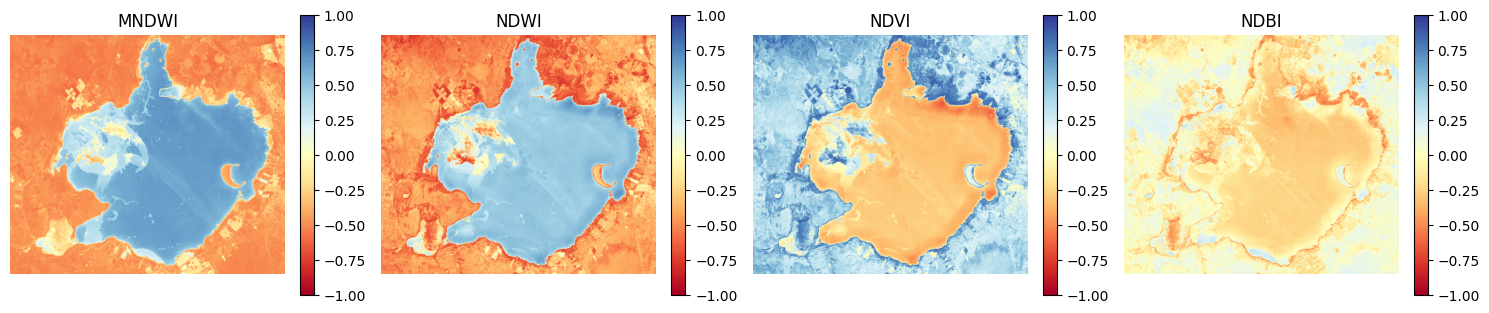

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
for ax, arr, title in zip(axes, [mndwi_local, ndwi_local, ndvi_local, ndbi_local], ["MNDWI", "NDWI", "NDVI", "NDBI"]):
    im = ax.imshow(arr, cmap="RdYlBu", vmin=-1, vmax=1)
    ax.set_title(title)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

## 4. Server-side vs local — why results can differ slightly

Even on "the same" image, values won't always match to the last decimal:

- **Resampling**: the server-side export applies its own resampling at the requested `scale`; if you export at a different scale than the one implicitly used in an earlier step, pixel alignment shifts slightly.
- **Masking**: `updateMask` on the EE side removes cloud pixels before they're ever written to the GeoTIFF; a local recompute has no such mask unless you also exported and reapplied it.
- **CRS/reprojection**: if the export CRS differs from the native collection CRS, EE reprojects during export — this changes pixel values at edges via resampling.

None of this is a bug — it's why we treat "compute on EE, download the final product" as the standard path, and reserve local recompute for cases where we already have the raster and don't want another `getInfo()`/export round-trip.

## Exercise 3.1

Acquire another sentinel 2 image from the ROI's below and export it to drive (you can start from the top)

1. Compute the indices locally and on the server side

2. Compare the indices and note the difference

In [ ]:
NAKURU_ROI = ee.Geometry.Polygon([
    [36.045150257654164, -0.41882934935973415],
    [36.13441417366979, -0.41882934935973415],
    [36.13441417366979, -0.29935539913088666],
    [36.045150257654164, -0.29935539913088666],
    [36.045150257654164, -0.41882934935973415],
])

ELEMENTAITA_ROI = ee.Geometry.Polygon([
            [36.20503005704847,-0.4844042871968538],
            [36.27541122159925,-0.4844042871968538],
            [36.27541122159925,-0.3992627836576272],
            [36.20503005704847,-0.3992627836576272],
            [36.20503005704847,-0.4844042871968538]
        ])
BARINGO_ROI = ee.Geometry.Polygon([
            [35.98987673288601,0.4361077040885743],
            [36.180764184057885,0.4361077040885743],
            [36.180764184057885,0.7574399496732773],
            [35.98987673288601,0.7574399496732773],
            [35.98987673288601,0.4361077040885743]
        ])
